# Stock_Analysis_Project


In [6]:
# install libraries
!pip install -q yfinance pandas numpy matplotlib openpyxl

In [7]:
# Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Download Data
stocks = ['AAPL', 'TSLA', 'MSFT']

data = yf.download(stocks, start='2022-01-01', end='2024-01-01')

data.head()

[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AAPL        MSFT        TSLA        AAPL        MSFT   
Date                                                                     
2022-01-03  178.103683  323.160797  399.926666  178.955022  326.298281   
2022-01-04  175.843246  317.619568  383.196655  179.013714  323.595270   
2022-01-05  171.165878  305.426788  362.706665  176.303203  314.781319   
2022-01-06  168.308456  303.013306  354.899994  171.537633  307.666442   
2022-01-07  168.474823  303.167847  342.320007  170.402543  305.542672   

Price                          Low                                Open  \
Ticker            TSLA        AAPL        MSFT        TSLA        AAPL   
Date                                                                     
2022-01-03  400.356659  173.895982  318.362860  378.679993  174.013402   
2022-01-04  402.666656  175.275693  314.829607  374.350006  178.710370   
2022-01-05  390.113342  170.891889  305.040642  360.336670  175.755224   
2022-01-06  362.666656  167.956182  300.706035  340.166656  168.993430   
2022-01-07  360.309998  167.359291  299.354585  336.666656  169.179371   

Price                                  Volume                       
Ticker            MSFT        TSLA       AAPL      MSFT       TSLA  
Date                                                                
2022-01-03  323.740031  382.583344  104487900  28865100  103931400  
2022-01-04  323.238055  396.516663   99310400  32674300  100248300  
2022-01-05  314.578568  382.216675   94537600  40054300   80119800  
2022-01-06  302.308568  359.000000   96904000  39646100   90336600  
2022-01-07  303.274024  360.123322   86709100  32720000   84164700

In [9]:
# analyze closing price for returns
close_data = data['Close']
close_data.head()

Ticker,AAPL,MSFT,TSLA
Date,,,
2022-01-03,178.103683,323.160797,399.926666
2022-01-04,175.843246,317.619568,383.196655
2022-01-05,171.165878,305.426788,362.706665
2022-01-06,168.308456,303.013306,354.899994
2022-01-07,168.474823,303.167847,342.320007


In [11]:
# Check Missing Values
close_data.isnull().sum()


Ticker
AAPL    0
MSFT    0
TSLA    0
dtype: int64

In [12]:
# Handle Missing Values
close_data = close_data.dropna()

In [13]:
# Reset Index
close_data = close_data.reset_index()
close_data.head()

Ticker,Date,AAPL,MSFT,TSLA
0,2022-01-03,178.103683,323.160797,399.926666
1,2022-01-04,175.843246,317.619568,383.196655
2,2022-01-05,171.165878,305.426788,362.706665
3,2022-01-06,168.308456,303.013306,354.899994
4,2022-01-07,168.474823,303.167847,342.320007


In [14]:
# Calculate Daily Returns
returns = close_data[['AAPL','MSFT','TSLA']].pct_change()
returns.head()

Ticker,AAPL,MSFT,TSLA
0,NaN,NaN,NaN
1,-0.012692,-0.017147,-0.041833
2,-0.026600,-0.038388,-0.053471
3,-0.016694,-0.007902,-0.021523
4,0.000988,0.000510,-0.035447


In [15]:
# Average Return
returns.mean()

Ticker
AAPL    0.000302
MSFT    0.000456
TSLA   -0.000230
dtype: float64

In [17]:
# Volatility
returns.std()

Ticker
AAPL    0.018316
MSFT    0.019355
TSLA    0.037905
dtype: float64

### 🚀 Key Insight from the Data

In [ ]:
 Stock   Risk Level 
 AAPL    Low risk        
 MSFT    Low-medium risk 
 TSLA    High risk       


## Visualization of Stock Trends

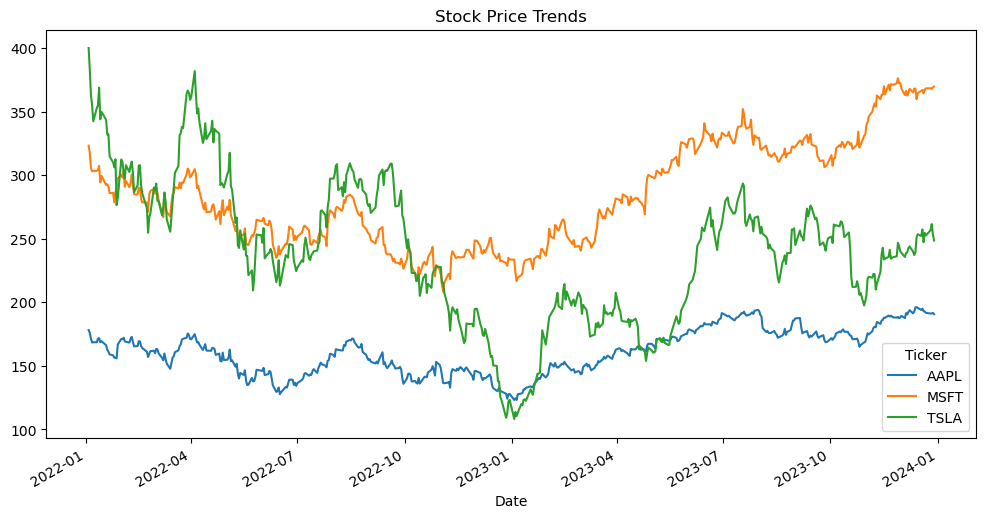

In [18]:
import matplotlib.pyplot as plt

close_data.set_index('Date', inplace=True)

close_data.plot(figsize=(12,6))
plt.title("Stock Price Trends")
plt.show()

## CHART

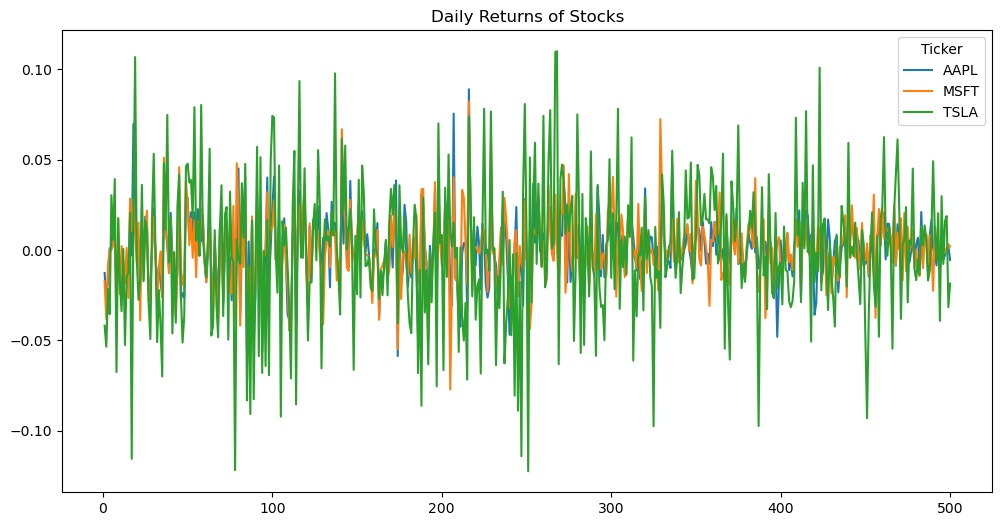

In [19]:
returns.plot(figsize=(12,6))
plt.title("Daily Returns of Stocks")
plt.show()

In [21]:
# Export Clean Excel Report
with pd.ExcelWriter("stock_analysis_report.xlsx") as writer:
    close_data.to_excel(writer, sheet_name="Stock Prices")
    returns.to_excel(writer, sheet_name="Daily Returns")

In [25]:
file_path = "stock_analysis_report.xlsx"

with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    close_data.to_excel(writer, sheet_name="Stock Prices")
    returns.to_excel(writer, sheet_name="Daily Returns")

print("File saved successfully!")

File saved successfully!


### FINAL PROJECT SUMMARY

In [28]:
summary = {
    "AAPL Avg Return": returns["AAPL"].mean(),
    "MSFT Avg Return": returns["MSFT"].mean(),
    "TSLA Avg Return": returns["TSLA"].mean(),
    
    "AAPL Volatility": returns["AAPL"].std(),
    "MSFT Volatility": returns["MSFT"].std(),
    "TSLA Volatility": returns["TSLA"].std()
}

summary

{'AAPL Avg Return': np.float64(0.0003022341727666862),
 'MSFT Avg Return': np.float64(0.0004556335914938039),
 'TSLA Avg Return': np.float64(-0.0002300182107800044),
 'AAPL Volatility': 0.01831589288774599,
 'MSFT Volatility': 0.019355446008066157,
 'TSLA Volatility': 0.03790540743413315}

### FINAL INSIGHT

In [ ]:
“Microsoft showed the highest average return with relatively low risk, 
making it the best risk-adjusted performer. 
Tesla showed the highest volatility, indicating high risk and unstable returns.”

# Project Description

In [ ]:
This project analyzes historical stock market data for Apple (AAPL), Microsoft (MSFT), and Tesla (TSLA) using Python.

The analysis includes:
- Data collection using Yahoo Finance (yfinance)
- Data cleaning and preprocessing using Pandas
- Calculation of daily returns using percentage change
- Risk analysis using volatility (standard deviation)
- Visualization of stock trends using Matplotlib
- Exporting structured results to Excel for reporting

The goal is to compare stock performance and risk levels to understand investment behavior and financial trends.